# BISINDO Skeleton Motion Analysis

This notebook performs a comprehensive kinematic analysis of skeleton landmark displacements from the BISINDO video dataset. The analysis pipeline is divided into three main stages:
1. **Data Acquisition** — Recursively loading individual coordinate data from Excel exports.
2. **Motion Feature Engineering** — Computing inter-frame Euclidean displacements per keypoint.
3. **Statistical Aggregation & Visualization** — Summarizing motion intensity per body region and generating academic-style visualizations for publication.

---

## 1. Data Acquisition

We load all `.xlsx` files from the `data/excel` directory. Each file is validated for the presence of required kinematic columns: `frame`, `keypoint_id`, `x`, and `y`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
import os
from pathlib import Path

# ---------------------------------------------------
# Path Configuration
# ---------------------------------------------------
INPUT_DIR = "../data/excel"
OUTPUT_DIR = "../data/results"

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

data_frames = []
processed_list = []
skipped_list = []

print("=" * 60)
print("  STARTING DATA LOADING")
print("=" * 60)

for root, dirs, files in os.walk(INPUT_DIR):
    for file in sorted(files):
        if not file.lower().endswith(".xlsx"): continue

        file_path = os.path.join(root, file)
        try:
            temp_df = pd.read_excel(file_path)
            temp_df.columns = temp_df.columns.str.strip().str.lower()

            required = ['frame', 'keypoint_id', 'x', 'y']
            if not all(col in temp_df.columns for col in required):
                skipped_list.append(file_path)
                continue

            # Metadata Injection
            temp_df['label'] = os.path.basename(root)
            temp_df['video_id'] = file.replace(".xlsx", "")
            
            data_frames.append(temp_df)
            processed_list.append(file_path)
            # print(f"[OK] Loaded {len(temp_df):>6} rows from {file}")

        except Exception as e:
            print(f"[ERR] Failed to load {file}: {e}")

print("\n" + "=" * 60)
print(f"Successfully Processed: {len(processed_list)} files")
print(f"Skipped/Failed:         {len(skipped_list)} files")
print("=" * 60)

if not data_frames:
    raise ValueError("No valid data loaded. Please check your data/excel directory.")

full_dataset = pd.concat(data_frames, ignore_index=True)
print(f"\nConsolidated Dataset Shape: {full_dataset.shape}")

  STARTING DATA LOADING

Successfully Processed: 180 files
Skipped/Failed:         0 files

Consolidated Dataset Shape: (3234976, 7)


## 2. Ekstraksi Fitur Gerak

Perpindahan antar-frame dihitung sebagai jarak Euclidean antara posisi keypoint pada frame $t$ dan frame $t-1$:

$$d = \sqrt{(x_t - x_{t-1})^2 + (y_t - y_{t-1})^2}$$

Landmark yang hilang (koordinat pada $(0, 0)$) dikeluarkan dari perhitungan. Keypoint dikelompokkan ke dalam empat bagian tubuh fungsional:

| Bagian | Kode | ID Keypoint |
|-----------|------|-------------|
| Tangan Kiri | `GL` | 0–20 |
| Tangan Kanan| `GR` | 21–41 |
| Mulut     | `GM` | 42–60 |
| Pose      | `GP` | 61–85 |
| Upper Limb| `GU` | 72–83 (Subset GP)|
| Pose tanpa Upper Limb| `GP_non_GU` | 61–71, 84–85 |

In [2]:
print("Computing motion features...")

# 1. Sorting for time-series consistency
full_dataset = full_dataset.sort_values(by=['video_id', 'keypoint_id', 'frame']).reset_index(drop=True)

# 2. Calculate lagged positions
full_dataset['prev_x'] = full_dataset.groupby(['video_id', 'keypoint_id'])['x'].shift(1)
full_dataset['prev_y'] = full_dataset.groupby(['video_id', 'keypoint_id'])['y'].shift(1)

# 3. Validity mask for non-zero coordinates
full_dataset['is_valid_curr'] = ~((full_dataset['x'] == 0) & (full_dataset['y'] == 0))
full_dataset['is_valid_prev'] = ~((full_dataset['prev_x'] == 0) & (full_dataset['prev_y'] == 0))
full_dataset['is_valid_motion'] = full_dataset['is_valid_curr'] & full_dataset['is_valid_prev']

# 4. Euclidean Displacement
full_dataset['dx'] = full_dataset['x'] - full_dataset['prev_x']
full_dataset['dy'] = full_dataset['y'] - full_dataset['prev_y']
full_dataset['displacement'] = np.sqrt(full_dataset['dx']**2 + full_dataset['dy']**2)
full_dataset.loc[~full_dataset['is_valid_motion'], 'displacement'] = np.nan

# 5. Semantic Body Part Mapping
def get_body_part_label(kp_id):
    if kp_id <= 20:   return 'GL'
    elif kp_id <= 41: return 'GR'
    elif kp_id <= 60: return 'GM'
    else:             return 'GP'

full_dataset['body_part'] = full_dataset['keypoint_id'].apply(get_body_part_label)

valid_motion_rows = full_dataset['displacement'].notna().sum()
print(f"Total Data Points: {len(full_dataset):,}")
print(f"Valid Motion Points: {valid_motion_rows:,} ({(valid_motion_rows/len(full_dataset)*100):.1f}%)")

# Duplicate Upper Limb (GU) so GP stays intact
gu_data = full_dataset[full_dataset['keypoint_id'].isin(range(72, 84))].copy()
gu_data['body_part'] = 'GU'
gp_non_gu_data = full_dataset[(full_dataset['keypoint_id'] >= 61) & (full_dataset['keypoint_id'] <= 85) & ~full_dataset['keypoint_id'].isin(range(72, 84))].copy()
gp_non_gu_data['body_part'] = 'GP_non_GU'
full_dataset = pd.concat([full_dataset, gu_data, gp_non_gu_data], ignore_index=True)


Computing motion features...
Total Data Points: 3,234,976
Valid Motion Points: 2,424,502 (74.9%)


## 3. Agregasi Statistik dan Visualisasi

Displacement yang valid diagregasi untuk menghasilkan statistik deskriptif: **Rata-rata**, **Median**, **Simpangan Baku**, **Jumlah**, dan **Rasio Gerak Relatif**. Hasil diekspor ke CSV dan divisualisasikan menggunakan chart yang siap untuk publikasi.

In [3]:
print("Aggregating results...")

valid_data = full_dataset[full_dataset['displacement'].notna()].copy()

results_summary = (
    valid_data
    .groupby('body_part')['displacement']
    .agg(
        mean='mean',
        median='median',
        std='std',
        sum='sum',
        count='count'
    )
    .sort_values(by='mean', ascending=False)
)

total_displacement = results_summary['sum'].sum()
results_summary['ratio'] = results_summary['sum'] / total_displacement
results_summary['rank'] = results_summary['mean'].rank(ascending=False).astype(int)

# Export Summary to CSV
summary_csv_path = os.path.join(OUTPUT_DIR, "motion_analysis_summary.csv")
results_summary.to_csv(summary_csv_path)
print(f"Summary exported to: {summary_csv_path}")

print("\n--- Global Motion Summary ---")
print(results_summary.to_string())

Aggregating results...
Summary exported to: ../data/results\motion_analysis_summary.csv

--- Global Motion Summary ---
               mean    median       std            sum   count     ratio  rank
body_part                                                                     
GL         0.230064  0.199774  0.152416   41834.613284  181839  0.092784     1
GR         0.212904  0.186289  0.137102  125173.911764  587937  0.277620     2
GU         0.206020  0.129318  0.206433   92980.965823  451320  0.206220     3
GP         0.130212  0.068639  0.165738  122432.020169  940250  0.271539     4
GP_non_GU  0.060236  0.045654  0.057331   29451.054347  488930  0.065319     5
GM         0.054598  0.044897  0.039288   39008.927392  714476  0.086517     6


### 3.1 Visualisasi Akademik (Gaya Q1/Skripsi)

Visualisasi berikut dibuat dengan pengaturan yang cocok untuk publikasi ilmiah dan menggunakan warna agar tiap kategori mudah dibedakan. 

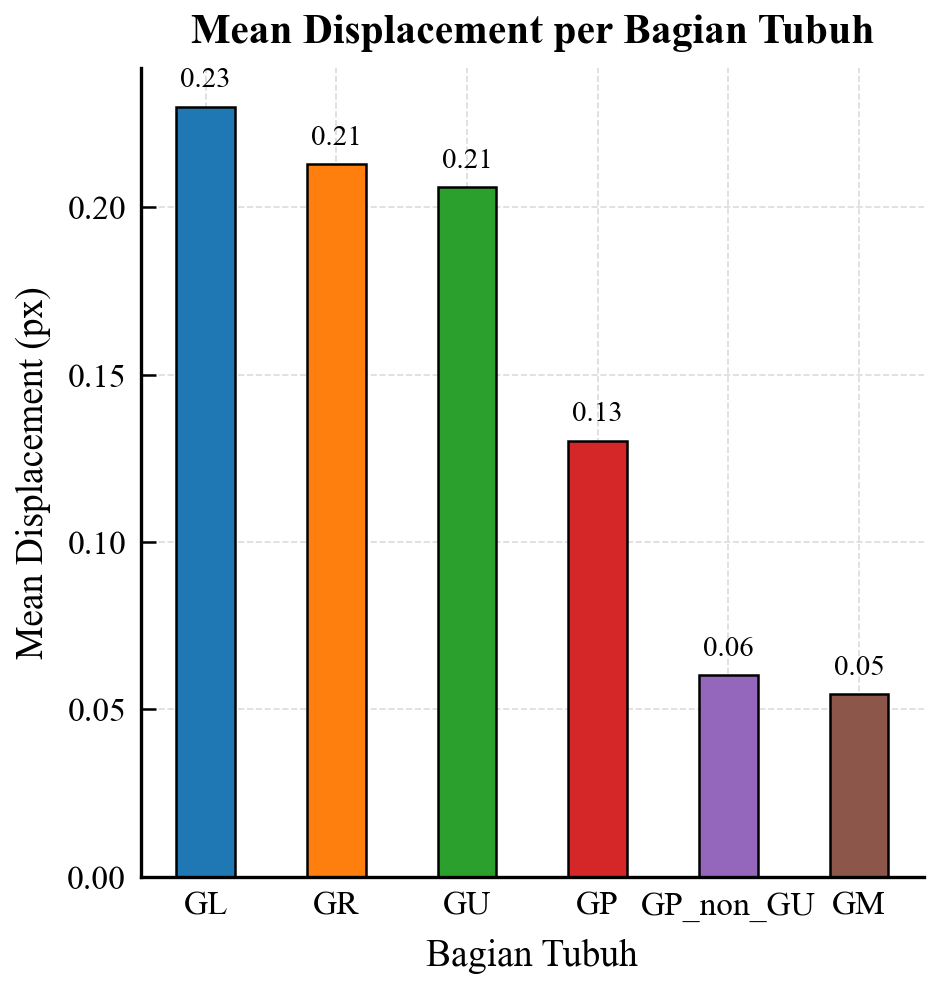

[SAVED] ../data/results\fig_01_mean.png


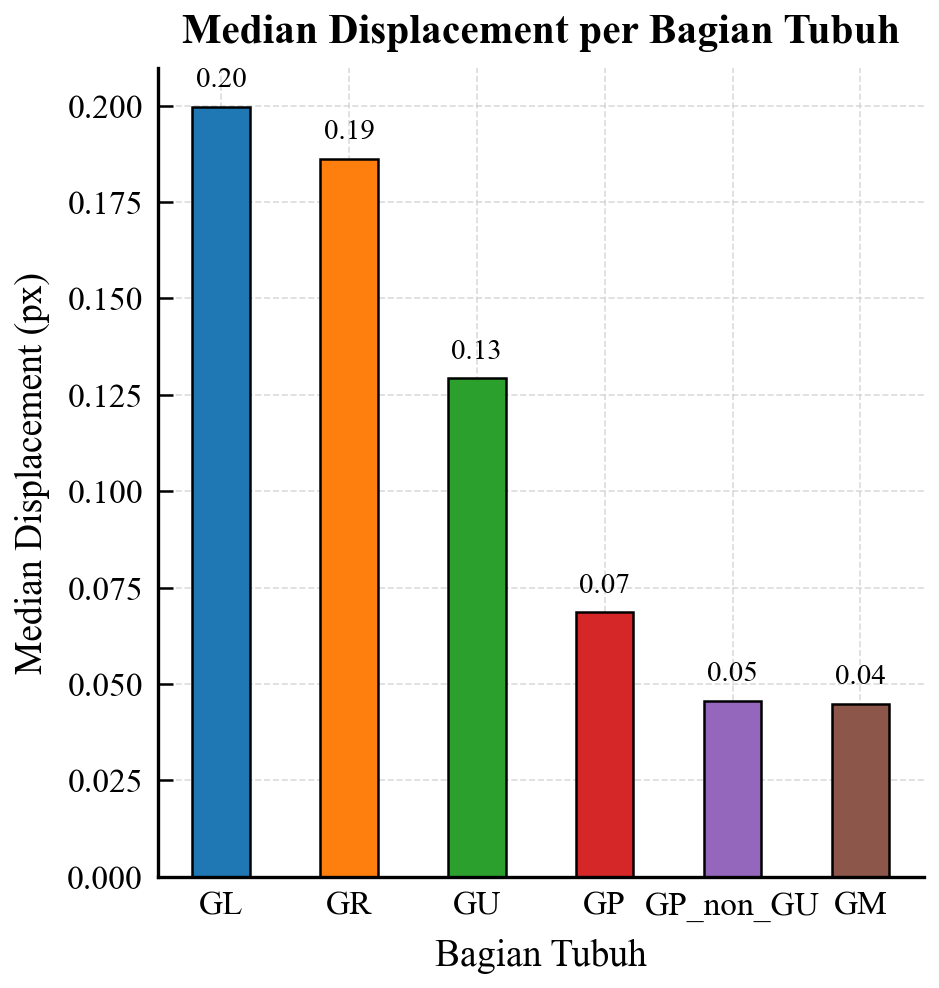

[SAVED] ../data/results\fig_02_median.png


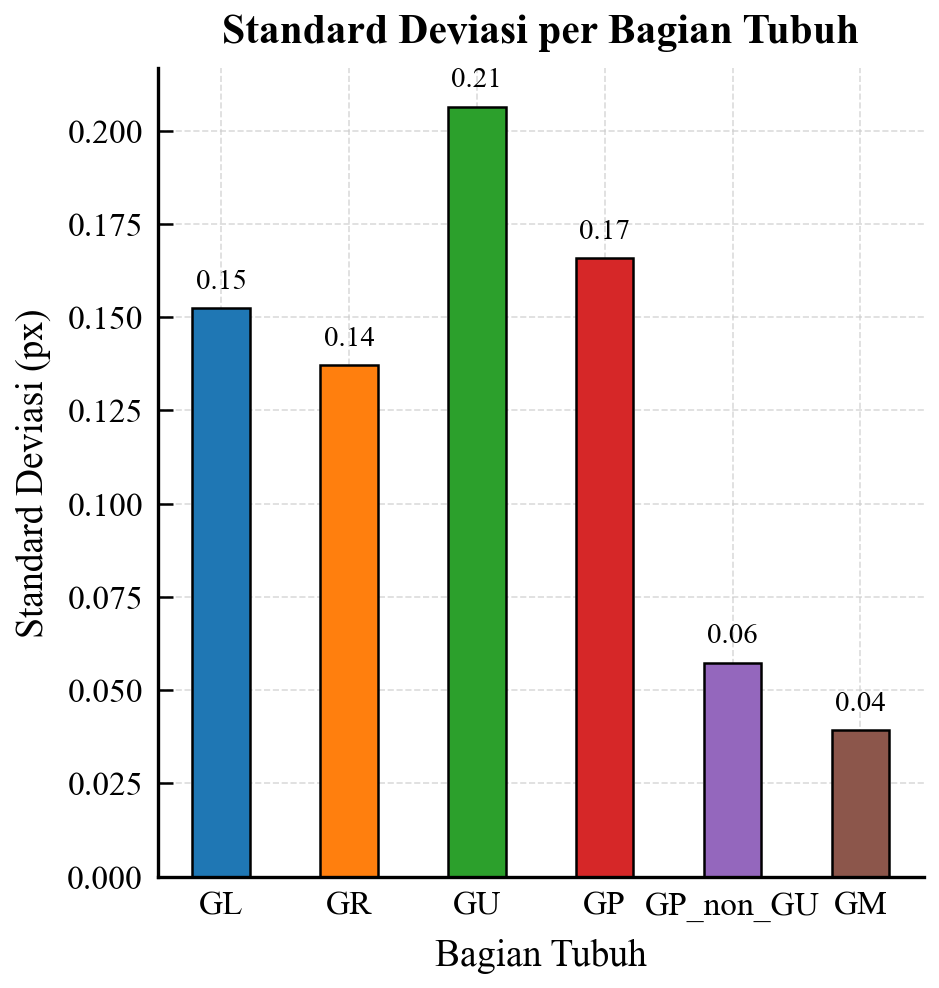

[SAVED] ../data/results\fig_03_std.png


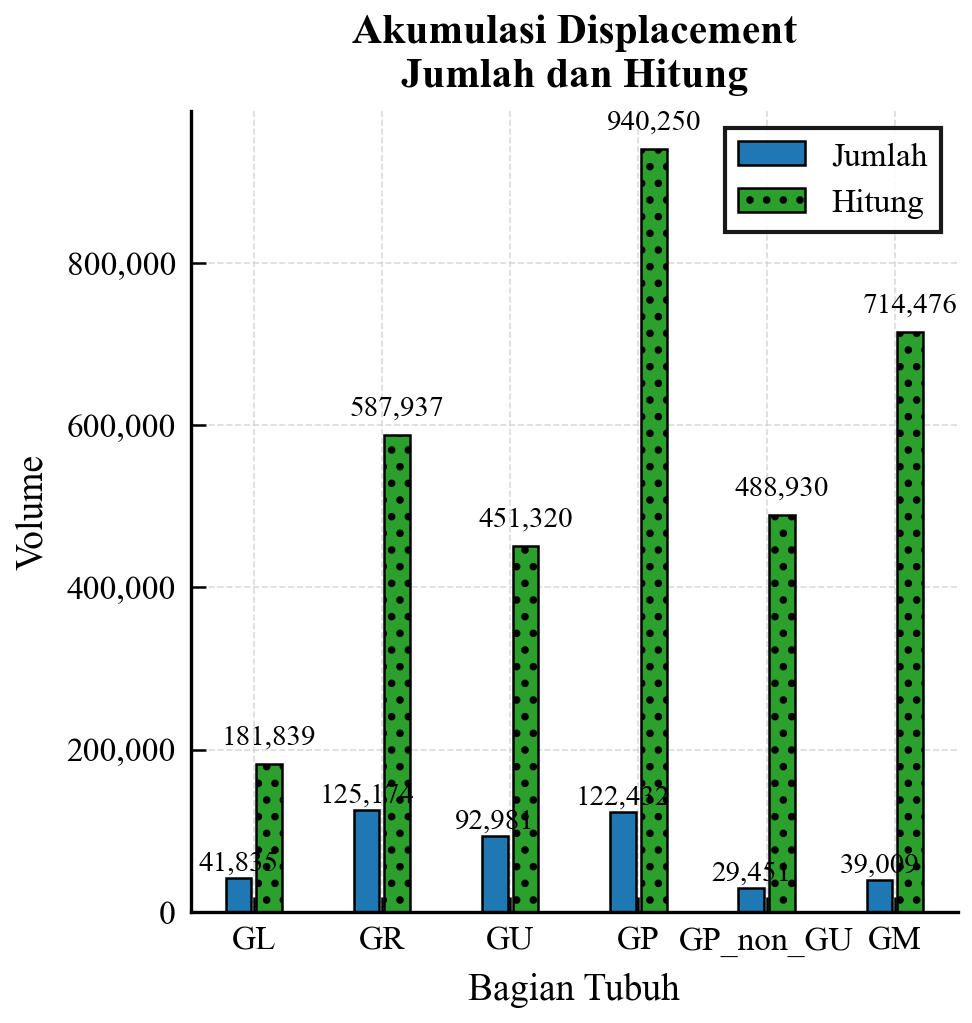

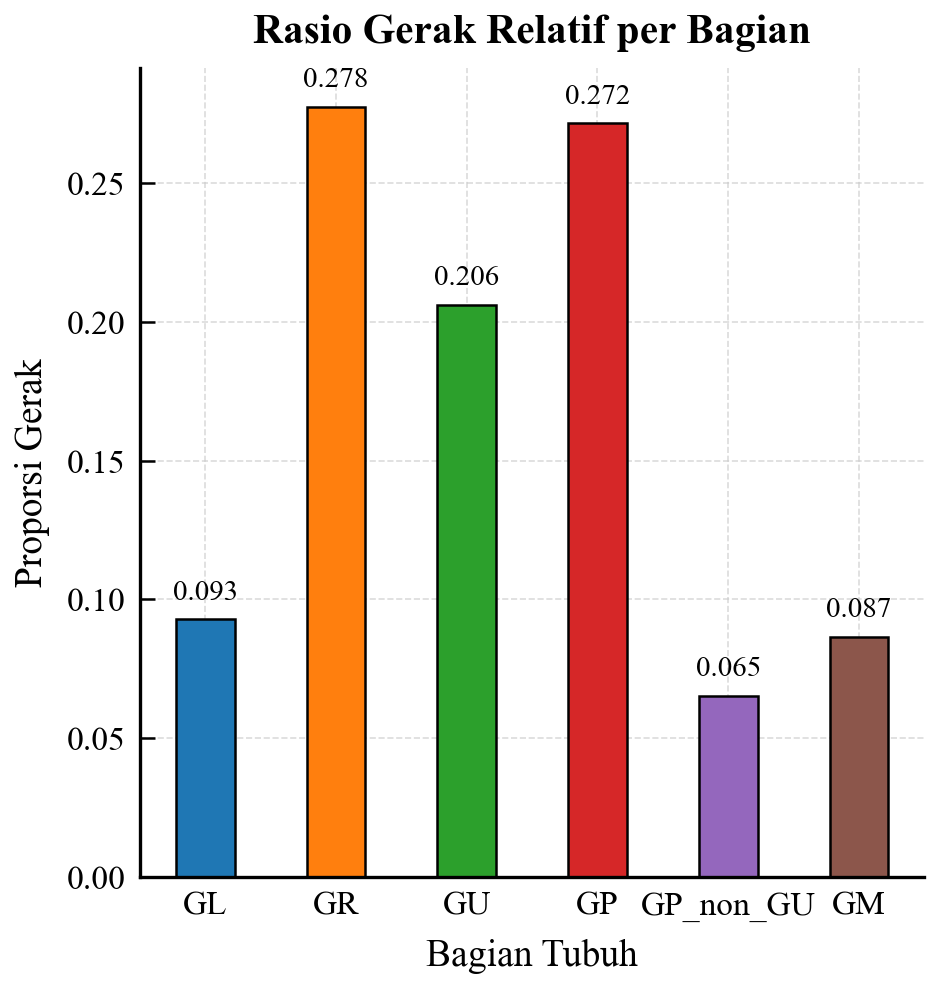

[SAVED] ../data/results\fig_05_ratio.png


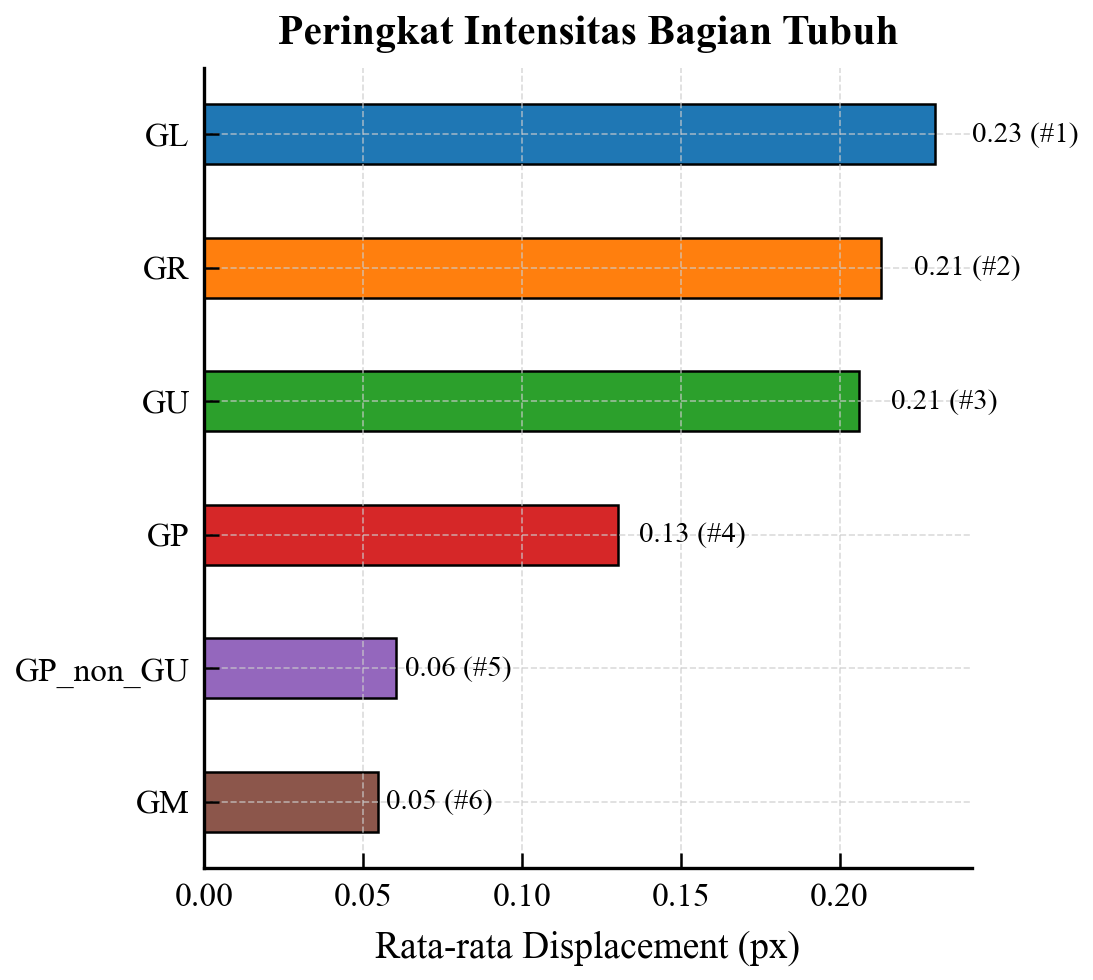


Analisis selesai. Semua artefak disimpan ke /data/results/


In [4]:
# ===================================================
## KONFIGURASI GLOBAL — Gaya Artikel Ilmiah
# ===================================================
matplotlib.rcParams.update({
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 9,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 8,
    'axes.linewidth'     : 0.8,
    'xtick.direction'    : 'in',
    'ytick.direction'    : 'in',
    'xtick.major.width'  : 0.6,
    'ytick.major.width'  : 0.6,
    'axes.grid'          : True,
    'grid.linewidth'     : 0.4,
    'grid.linestyle'     : '--',
    'grid.color'         : '#CCCCCC',
    'grid.alpha'         : 0.7,
    'figure.dpi'         : 300,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.05,
})

COLORS  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
HATCHES = ['', '///', '...', 'xxx', '++', 'OO']
BAR_EC  = 'black'
BAR_LW  = 0.6
BAR_W   = 0.45
ANNOT_FS = 7
FIG_W = 3.3
FIG_H = FIG_W * 1.05

body_parts = results_summary.index.tolist()
n = len(body_parts)
x = np.arange(n)

def annotate_bars(ax, bars, values, fmt='{:.2f}'):
    y_max = max(b.get_height() for b in bars)
    pad = y_max * 0.018 if y_max > 0 else 0.01
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + pad,
            fmt.format(val),
            ha='center', va='bottom', fontsize=ANNOT_FS
        )

def style_ax(ax, ylabel='', title=''):
    ax.set_title(title, pad=6)
    ax.set_xlabel('Bagian Tubuh')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(body_parts)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)

def single_bar(vals, ylabel, title, filename, fmt='{:.2f}', y_fmt=None):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    bars = ax.bar(
        x, vals, width=BAR_W,
        color=[COLORS[i % len(COLORS)] for i in range(n)],
        edgecolor=BAR_EC, linewidth=BAR_LW
    )
    annotate_bars(ax, bars, vals, fmt=fmt)
    style_ax(ax, ylabel=ylabel, title=title)
    if y_fmt: ax.yaxis.set_major_formatter(mticker.FuncFormatter(y_fmt))
    
    final_path = os.path.join(OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(final_path)
    plt.show()
    print(f'[SAVED] {final_path}')

# GRAFIK 1: Rata-rata Displacement
single_bar(results_summary['mean'].values, 'Mean Displacement (px)', 
           'Mean Displacement per Bagian Tubuh', 'fig_01_mean.png')

# GRAFIK 2: Median Displacement
single_bar(results_summary['median'].values, 'Median Displacement (px)', 
           'Median Displacement per Bagian Tubuh', 'fig_02_median.png')

# GRAFIK 3: Simpangan Baku
single_bar(results_summary['std'].values, 'Standard Deviasi (px)', 
           'Standard Deviasi per Bagian Tubuh', 'fig_03_std.png')

# GRAFIK 4: Jumlah & Count
BAR_W_G = 0.20
offsets = [-BAR_W_G * 0.6, BAR_W_G * 0.6]
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
g4_cfg = [
    ('Jumlah', results_summary['sum'].values,   COLORS[0], HATCHES[0], '{:,.0f}'),
    ('Hitung', results_summary['count'].values, COLORS[2], HATCHES[2], '{:,.0f}'),
]
for (lbl, vals, color, hatch, fmt_g), offset in zip(g4_cfg, offsets):
    bars = ax.bar(x + offset, vals, width=BAR_W_G, label=lbl, 
                  color=color, hatch=hatch, edgecolor=BAR_EC, linewidth=BAR_LW)
    annotate_bars(ax, bars, vals, fmt=fmt_g)
style_ax(ax, ylabel='Volume', title='Akumulasi Displacement\nJumlah dan Hitung')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(loc='upper right', framealpha=0.9, edgecolor='black', fancybox=False)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_04_sum_count.png'))
plt.show()

# GRAFIK 5: Rasio Gerak
single_bar(results_summary['ratio'].values, 'Proporsi Gerak', 
           'Rasio Gerak Relatif per Bagian', 'fig_05_ratio.png', fmt='{:.3f}')

# GRAFIK 6: Peringkat
rank_df = results_summary.sort_values('rank')
y_labels = rank_df.index.tolist()
y_pos = np.arange(len(y_labels))
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
bars = ax.barh(y_pos, rank_df['mean'].values, height=0.45, 
               color=[COLORS[i % len(COLORS)] for i in range(len(y_labels))], 
               edgecolor=BAR_EC, linewidth=BAR_LW)
for bar, rnk, m_val in zip(bars, rank_df['rank'], rank_df['mean']):
    ax.text(bar.get_width() + bar.get_width() * 0.05, bar.get_y() + bar.get_height() / 2, 
            f'{m_val:.2f} (#{int(rnk)})', va='center', fontsize=ANNOT_FS)
ax.set_yticks(y_pos); ax.set_yticklabels(y_labels)
ax.set_xlabel('Rata-rata Displacement (px)'); ax.set_title('Peringkat Intensitas Bagian Tubuh', pad=6)
ax.invert_yaxis(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_06_rank.png'))
plt.show()

print('\nAnalisis selesai. Semua artefak disimpan ke /data/results/')